# Diabetic retinopathy diagnosis using deep neural networks

**Preprocessing Pipeline**  
Author: Yelizaveta Kabanova  
Date: 2025/2026

## Imports

In [1]:
!pip install keras_preprocessing
!pip install tf_keras_vis

In [2]:
import numpy as np
import pandas as pd
import cv2
import os
import pathlib
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle
import time
import gc
import warnings
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (precision_score, accuracy_score, recall_score,
                             f1_score, cohen_kappa_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve,
                             auc, balanced_accuracy_score
                            )
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import Model
from keras_preprocessing.image import ImageDataGenerator
from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

sns.set_style("darkgrid")
sns.set_theme(palette="muted")

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

K.clear_session()
tf.compat.v1.reset_default_graph()

## Configuration

In [3]:
# ===============================
# Variables
# ===============================
# == path ==
DATA_DIR = pathlib.Path(r"C:\Users\eliza\Portfolio\blindness-detection")
RAW_DIR = DATA_DIR / "train_images"
TRAIN_CSV = DATA_DIR / 'train.csv'
PROC_DIR = DATA_DIR / "train_images_proc_v2"   # advanced preprocessing
BAL_DIR = DATA_DIR / 'train_images_bal_v2'     # oversampling + advanced preprocessing
RESULTS_PATH = "training_results.csv"
TEST_RESULTS_PATH = "test_experiment_results.csv"

# == Path for google Collab ==
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = pathlib.Path("/content/drive/MyDrive/Blindness-Detection")
# RAW_DIR = DATA_DIR / "train_images"
# TRAIN_CSV = DATA_DIR / 'train.csv'

# PROC_DIR = DATA_DIR / "train_images_proc_v2"

# BAL_DIR  = DATA_DIR / "train_images_bal_v2"

# RESULTS_PATH = DATA_DIR / "training_results.csv"
# TEST_RESULTS_PATH = DATA_DIR / "test_experiment_results.csv"

# == constants ==
IMG_CHANNELS = 3
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
EPOCHS = 30
NUM_CLASSES = 5
class_names = {
    0: "No DR",
    1: "Mild DR",
    2: "Moderate DR",
    3: "Severe DR",
    4: "Proliferative DR"
}

## Data Loading

In [4]:
# ============================================================
# Load Dataset
# ============================================================
train_full_df = pd.read_csv(TRAIN_CSV)

train_full_df['diagnosis_label'] = train_full_df['diagnosis'].map(class_names)
train_full_df["image_path"] = train_full_df["id_code"].apply(
    lambda x: str(DATA_DIR / "train_images" / f"{x}.png")
)

print("Dataset shape:", train_full_df.shape)
print(train_full_df.info())
train_full_df.head()

Dataset shape: (3662, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_code          3662 non-null   object
 1   diagnosis        3662 non-null   int64 
 2   diagnosis_label  3662 non-null   object
 3   image_path       3662 non-null   object
dtypes: int64(1), object(3)
memory usage: 114.6+ KB
None


,id_code,diagnosis,diagnosis_label,image_path
0,000c1434d8d7,2,Moderate DR,C:\Users\eliza\Portfolio\blindness-detection\t...
1,001639a390f0,4,Proliferative DR,C:\Users\eliza\Portfolio\blindness-detection\t...
2,0024cdab0c1e,1,Mild DR,C:\Users\eliza\Portfolio\blindness-detection\t...
3,002c21358ce6,0,No DR,C:\Users\eliza\Portfolio\blindness-detection\t...
4,005b95c28852,0,No DR,C:\Users\eliza\Portfolio\blindness-detection\t...


In [5]:
# ============================================================
# Missing Values & File Validation
# ============================================================
print("Missing values per column:")
print(train_full_df.isna().sum())

# Check if any images are missing on disk
missing_files = [p for p in train_full_df["image_path"] if not os.path.exists(p)]

print(f"Number of missing image files: {len(missing_files)}")

Missing values per column:
id_code            0
diagnosis          0
diagnosis_label    0
image_path         0
dtype: int64
Number of missing image files: 0


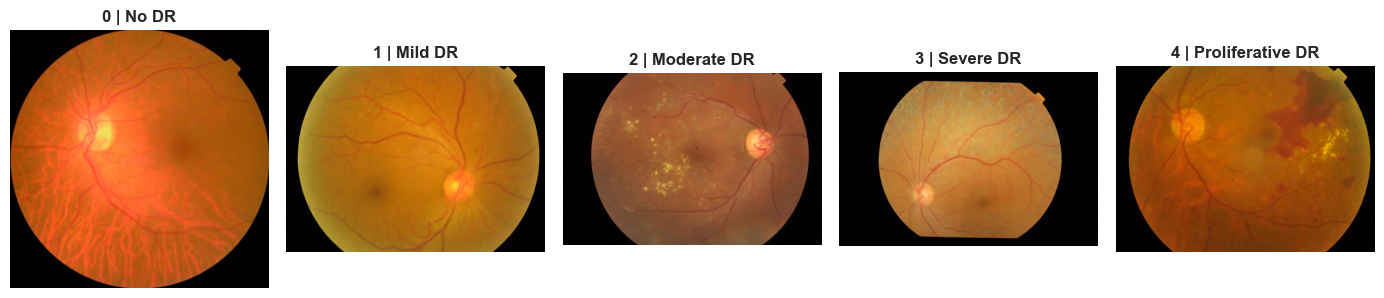

In [ ]:
# ============================================================
# Visual Inspection of Samples
# ============================================================
def visualize_samples(df):
    """
    Display one random image from each class.
    """
    sample_per_class = df.groupby('diagnosis').sample(1, random_state=SEED)
    plt.figure(figsize=(14, 10))
    for i, (idx, row) in enumerate(sample_per_class.iterrows()):
        img = cv2.imread(str(row['image_path']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(f'{row["diagnosis"]} | {row["diagnosis_label"]}',fontsize=12, weight="bold")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_samples(train_full_df)

## Exploratory Data Analysis (EDA)

> **Plan:**
> - Discover the distribution of classes
> - Discover the frequency of each classes
> - Discover the distribution of sices of images by classes
> - Find the number of blurred images
> - Find the number which may contain artifacts, be out of focus, underexposed, or overexposed.

### Class Distribution

=== Сlasses in the Dataset ===
diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


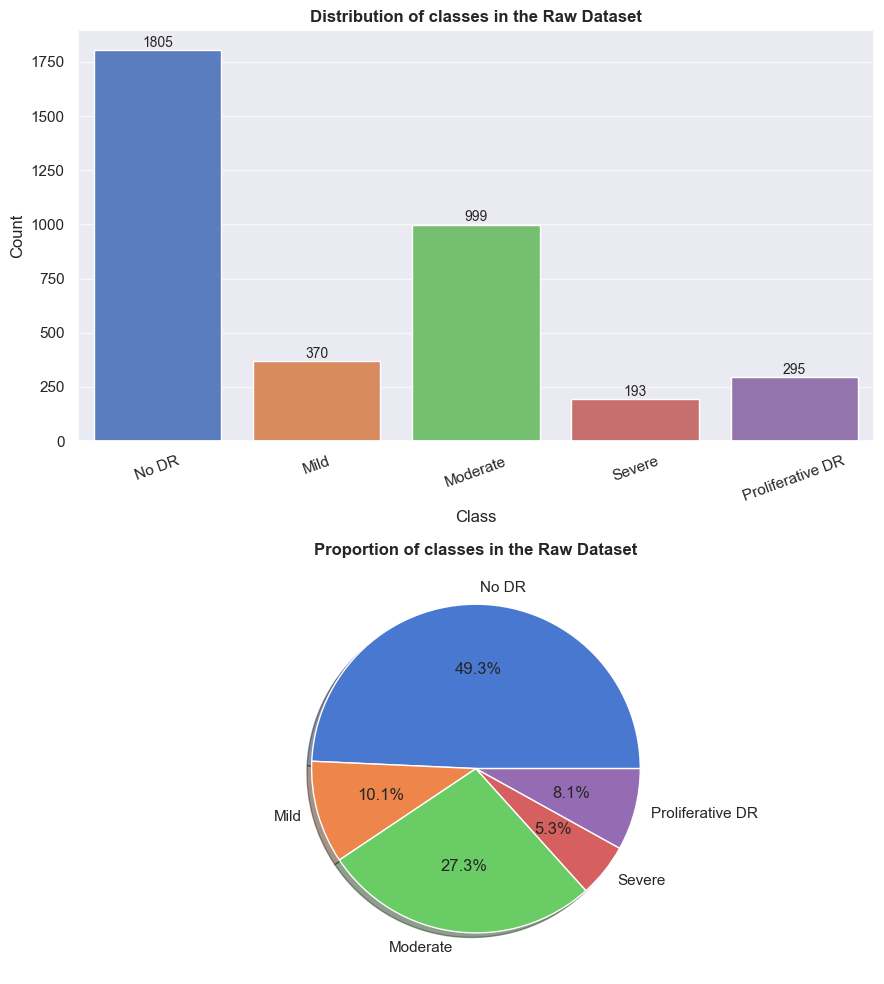

In [ ]:
# ============================================================
# Class Distribution Analysis
# ============================================================
def plot_class_distribution(df, title_prefix="Raw Dataset"):
    counts = df['diagnosis'].value_counts().reindex([0,1,2,3,4], fill_value=0)
    labels = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
    palette = sns.color_palette("muted")[0:5]

    fig, ax = plt.subplots(2, 1, figsize=(9, 10))
    # Barplot
    sns.barplot(x=counts.index, y=counts.values, palette=palette, ax=ax[0])
    for bar, count in zip(ax[0].patches, counts.values):
      height = bar.get_height()
      ax[0].text(
          bar.get_x() + bar.get_width()/2,  # по центру
          height + max(counts.values)*0.001,  # трохи над верхом
          str(count),
          ha='center',
          va='bottom',
          fontsize=10,
      )
    ax[0].set_title(f'Distribution of classes in the {title_prefix}', fontsize=12, weight="bold")
    ax[0].set_ylabel("Count")
    ax[0].set_xlabel("Class")
    ax[0].set_xticks(ticks=[0,1,2,3,4], labels=labels, rotation=20)
    ax[0].grid(axis="y", alpha=0.7)

    # Pie chart
    ax[1].pie(counts, autopct='%1.1f%%', shadow=True, colors=palette, labels=labels)
    ax[1].set_title(f'Proportion of classes in the {title_prefix}', fontsize=12, weight="bold")

    plt.tight_layout()
    plt.show()

print("=== Сlasses in the Dataset ===")
print(f"{train_full_df['diagnosis'].value_counts()}")
plot_class_distribution(train_full_df)

## Data Preprocessing

### Image Preprocessing

In [6]:
# ============================================================
# Image Preprocessing Functions
# ============================================================
def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        img = img[np.ix_(mask.any(axis = 1),mask.any(axis = 0))]
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return img

    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) 
        mask = gray_img > tol 
        check_shape = img[:,:,0][np.ix_(mask.any(1),mask.any(0))].shape[0]
        if (check_shape == 0): 
            return img 
        else:
            img1 = img[:,:,0][np.ix_(mask.any(1),mask.any(0))]
            img2 = img[:,:,1][np.ix_(mask.any(1),mask.any(0))]
            img3 = img[:,:,2][np.ix_(mask.any(1),mask.any(0))]
            img = np.stack([img1,img2,img3],axis=-1)
        return img

def preprocess_advanced(img, target_size=IMG_SIZE):
  img_cropped = crop_image_from_gray(img)
  img_resize = cv2.resize(img_cropped , (target_size, target_size), interpolation=cv2.INTER_AREA) # type: ignore
  blur = cv2.GaussianBlur(img_resize, (0,0), sigmaX=10)
  img_ben = cv2.addWeighted(img_resize, 4, blur, -4, 128)
  lab = cv2.cvtColor(img_ben, cv2.COLOR_RGB2LAB)
  l, a, b = cv2.split(lab)
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
  cl = clahe.apply(l)
  limg = cv2.merge((cl, a, b))
  img_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
  return img_clahe

In [7]:
# ============================================================
# Save Preprocessed Images
# ============================================================
def save_preprocessed(df, out_dir, pre_fn):
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)
    processed_rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Preprocessing -> {os.path.basename(out_dir)}"):
        img = cv2.imread(row["image_path"])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = pre_fn(img)
        out_path = os.path.join(out_dir, f"{row['id_code']}.png")
        cv2.imwrite(out_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        processed_rows.append({
            "id_code": row["id_code"],
            "diagnosis": row["diagnosis"],
            "image_path": out_path
        })
    return pd.DataFrame(processed_rows)

In [8]:
# ============================================================
# 3. Load Processed Images
# ==========================================================
def load_processed_images(proc_dir, train_csv):
    base_df = pd.read_csv(train_csv)
    diagnosis_map = dict(zip(base_df['id_code'], base_df['diagnosis']))
    image_files = sorted([f for f in os.listdir(proc_dir) if f.endswith(".png")])

    records = []
    for fname in image_files:
        id_code = fname.replace(".png", "")
        if id_code in diagnosis_map:
            diagnosis = diagnosis_map[id_code]
        else:
            base_id = id_code.split("_aug_")[0]
            diagnosis = diagnosis_map.get(base_id, np.nan)
        records.append({
            "id_code": id_code,
            "diagnosis": diagnosis,
            "image_path": str(proc_dir / fname)
        })
    df = pd.DataFrame(records)
    print(f"--- Loaded {len(df)} images from {os.path.basename(proc_dir)} ---")
    return df

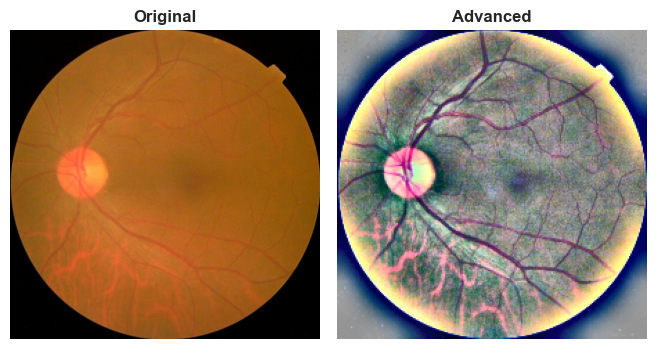

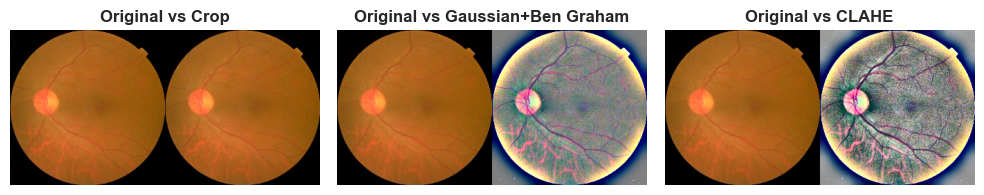

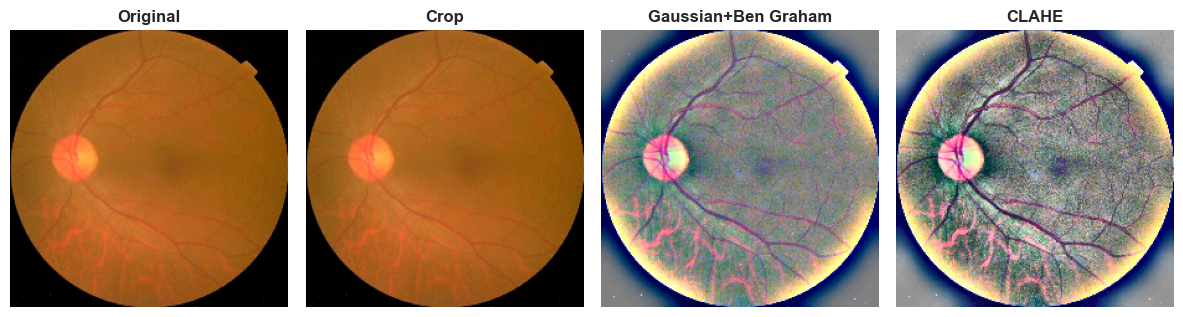

In [9]:
# ============================================================
# Preprocessing Visualization
# ============================================================
def random_image_from_dir(img_dir):
    files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png'))]
    return os.path.join(img_dir, random.choice(files))

def visualize_preprocessing(img_path, target_size=IMG_SIZE):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    adv = preprocess_advanced(img, target_size)

    plt.figure(figsize=(10, 4))
    for i, (title, im) in enumerate([
        ("Original", img),
        ("Advanced", adv)
    ]):
        plt.subplot(1, 3, i+1)
        plt.imshow(im)
        plt.title(title, fontsize=12, weight="bold")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def visualize_preprocessing_steps(img_path, target_size=IMG_SIZE):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (target_size, target_size))

    cropped = crop_image_from_gray(img)
    blur = cv2.GaussianBlur(cropped, (0,0), sigmaX=10) # type: ignore
    ben = cv2.addWeighted(cropped, 4, blur, -4, 128) # type: ignore
    lab = cv2.cvtColor(ben, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    clahe_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    pairs = [
        ("Original", "Crop", cropped),
        ("Original", "Gaussian+Ben Graham", ben),
        ("Original", "CLAHE", clahe_img)
    ]

    plt.figure(figsize=(10,4))
    for i, (orig_title, step_title, step_img) in enumerate(pairs, 1):
        plt.subplot(1, len(pairs), i)
        combined = np.hstack([img, step_img])  # Original + шаг рядом
        plt.imshow(combined)
        plt.title(f"{orig_title} vs {step_title}", fontsize=12, weight="bold")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    full_steps = [img, cropped, ben, clahe_img]
    titles = ["Original", "Crop", "Gaussian+Ben Graham", "CLAHE"]

    plt.figure(figsize=(12,4))
    for i, (title, im) in enumerate(zip(titles, full_steps), 1):
        plt.subplot(1, len(full_steps), i)
        plt.imshow(im)
        plt.title(title, fontsize=12, weight="bold")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

random_img_path = random_image_from_dir(RAW_DIR)
visualize_preprocessing(random_img_path, target_size=IMG_SIZE)
visualize_preprocessing_steps(random_img_path, target_size=IMG_SIZE)

### Augmentation

In [10]:
# ============================================================
# Data Augmentation
# ============================================================
def augment_image(img):
    funcs = [
        lambda x: cv2.flip(x, 1),
        lambda x: cv2.convertScaleAbs(x, alpha=1.2, beta=0),
        lambda x: cv2.convertScaleAbs(x, alpha=0.8, beta=0),
    ]
    def random_small_rotation(x, angle_range=15):
        angle = random.uniform(-angle_range, angle_range)
        h, w = x.shape[:2]
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        return cv2.warpAffine(x, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
    funcs.append(random_small_rotation)
    num_transforms = random.randint(1, 3)
    img_aug = img.copy()
    for f in random.sample(funcs, num_transforms):
        img_aug = f(img_aug)
    return img_aug


def augment_image_2(img):
    h, w = img.shape[:2]
    img_aug = img.copy().astype(np.float32)

    # ---------- Brightness ----------
    if random.random() < 0.7:
        alpha = random.uniform(0.8, 1.2)  # brightness_range
        img_aug = cv2.convertScaleAbs(img_aug, alpha=alpha, beta=0)

    # ---------- Horizontal Flip ----------
    if random.random() < 0.5:
        img_aug = cv2.flip(img_aug, 1)

    # ---------- Rotation + Shift + Zoom ----------
    if random.random() < 0.8:
        angle = random.uniform(-10, 10)
        scale = random.uniform(0.9, 1.1)

        tx = random.uniform(-0.1, 0.1) * w
        ty = random.uniform(-0.1, 0.1) * h

        M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
        M[:, 2] += (tx, ty)

        img_aug = cv2.warpAffine(
            img_aug,
            M,
            (w, h),
            borderMode=cv2.BORDER_REPLICATE  # аналог fill_mode='nearest'
        )
    # ---------- Rescale ----------
    img_aug = img_aug / 255.0

    return img_aug

### Class Balancing

In [11]:
# ============================================================
# Class Balancing Techniques
# ============================================================
def balance_classes(df, output_dir, img_size=IMG_SIZE):
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    balanced_rows = []
    for _, row in df.iterrows():
        src = row['image_path']
        dst_name = f"{row['id_code']}.png"
        dst_path = os.path.join(output_dir, dst_name)

        if not os.path.exists(dst_path):
            img = cv2.imread(src)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            cv2.imwrite(dst_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

        balanced_rows.append({
            'id_code': row['id_code'],
            'diagnosis': row['diagnosis'],
            'image_path': dst_path
        })

    counts = df['diagnosis'].value_counts()
    max_class_count = counts.max()

    for cls in counts.index:
        cls_df = df[df['diagnosis'] == cls]
        n = len(cls_df)
        extra_needed = int(max_class_count - n)

        for _ in tqdm(range(extra_needed), desc=f"Balancing {cls} -> {os.path.basename(output_dir)}"):
            row = cls_df.sample(1).iloc[0]
            img = cv2.imread(row['image_path'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img_aug = augment_image(img)
            aug_name = f"{row['id_code']}_aug_{random.randint(0, int(1e6))}.png"
            aug_path = os.path.join(output_dir, aug_name)
            cv2.imwrite(aug_path, cv2.cvtColor(img_aug, cv2.COLOR_RGB2BGR))
            balanced_rows.append({
                'id_code': os.path.splitext(aug_name)[0],
                'diagnosis': cls,
                'image_path': aug_path
            })

    balanced_df = pd.DataFrame(balanced_rows)
    return balanced_df

## Pipeline

In [ ]:
# ============================================================
# 9. Preprocessing Pipeline
# ============================================================
# ---------- Image preprocessing ----------

proc_df = save_preprocessed(
    train_full_df,
    out_dir = PROC_DIR,
    pre_fn = preprocess_advanced
)

# ---------- Class balancing ----------
balanced_df  = balance_classes(proc_df, BAL_DIR) # advanced + balanced

--- Loaded 3662 images from train_images_proc_v2 ---
Shape: (3662, 3)
--- Loaded 9025 images from train_images_bal_v2 ---
Oversampling: (9025, 3)
Found 7220 validated image filenames belonging to 5 classes.
Found 1805 validated image filenames belonging to 5 classes.
